# Data Engineering

In [1]:
%load_ext autoreload

In [2]:
%autoreload 2

In [3]:
import pandas as pd
import numpy as np
import wrds
import matplotlib.pyplot as plt
from functions import PrepareMacro

/Users/yandong/Documents/GitHub/Man-vs-machine/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
###################
# Connect to WRDS #
###################

db = wrds.Connection(yautoconnect=True )

WRDS recommends setting up a .pgpass file.
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


## IBES and CRSP

### 1) Create IBES CRSP Linking table

In [5]:
# 1.1 IBES: Get the list of IBES Tickers for US firms in IBES
_ibes1 = db.raw_sql("""
                        select ticker, cusip, cname, sdates
                        from ibes.id
                        where usfirm='1' 
                        and cusip != ''
                        """, date_cols=['sdates'])

In [6]:
# Create first and last 'start dates' for a given cusip

_ibes1_date = _ibes1.groupby(['ticker','cusip']).sdates.agg(['min', 'max'])\
.reset_index().rename(columns={'min':'fdate', 'max':'ldate'})

_ibes2 = pd.merge(_ibes1, _ibes1_date,how='left', on =['ticker','cusip'])
_ibes2 = _ibes2.sort_values(by=['ticker','cusip','sdates'])

# keep only the most recent company name
_ibes2 = _ibes2.loc[_ibes2.sdates == _ibes2.ldate].drop(['sdates'], axis=1)
_ibes2.head()

,ticker,cusip,cname,fdate,ldate
1,0000,87482X10,TALMER BANCORP,2014-02-20,2014-03-20
6,0001,26878510,EP ENGR CORP,2014-02-20,2019-10-17
7,0004,02504D10,AMERICAN CAPITAL,2014-02-20,2014-02-20
8,000R,14163310,CARECOM,2014-02-20,2014-02-20
9,000V,15117E10,CELLADON,2014-03-20,2014-03-20


In [7]:
# 1.2 CRSP: Get all permno-ncusip combinations
_crsp1 = db.raw_sql("""
                      select permno, ncusip, comnam, namedt, nameenddt
                      from crsp.stocknames where ncusip != ''
                      """, date_cols=['namedt', 'nameenddt'])

In [8]:
_crsp1

,permno,ncusip,comnam,namedt,nameenddt
0,10000,68391610,OPTIMUM MANUFACTURING INC,1986-01-07,1987-06-11
1,10001,39040610,GREAT FALLS GAS CO,1986-01-09,1993-11-21
2,10001,29274A10,ENERGY WEST INC,1993-11-22,2008-02-04
3,10001,29274A20,ENERGY WEST INC,2008-02-05,2009-08-03
4,10001,29269V10,ENERGY INC,2009-08-04,2009-12-17
...,...,...,...,...,...
77831,93434,78513510,S & W SEED CO,2010-06-14,2024-10-17
77832,93434,78513530,S & W SEED CO,2024-10-18,2024-12-31
77833,93435,82936G20,SINO CLEAN ENERGY INC,2010-06-14,2012-05-18
77834,93436,88160R10,TESLA MOTORS INC,2010-06-29,2017-02-01


In [9]:
_crsp1_fnamedt = _crsp1.groupby(['permno','ncusip']).namedt.min().reset_index()

_crsp1_lnameenddt = _crsp1.groupby(['permno','ncusip']).nameenddt.max().reset_index()

# merge 
_crsp1_dtrange = pd.merge(_crsp1_fnamedt, _crsp1_lnameenddt, \
                          on = ['permno','ncusip'], how='inner')

_crsp1 = _crsp1.drop(['namedt'],axis=1).rename(columns={'nameenddt':'enddt'})
_crsp2 = pd.merge(_crsp1, _crsp1_dtrange, on =['permno','ncusip'], how='inner')

# keep only most recent company name
_crsp2 = _crsp2.loc[_crsp2.enddt ==_crsp2.nameenddt].drop(['enddt'], axis=1)

In [10]:
# 1.3 Create CUSIP Link Table

_link1_1 = pd.merge(_ibes2, _crsp2, how='inner', left_on='cusip', right_on='ncusip')\
.sort_values(['ticker','permno','ldate'])

_link1_1_tmp = _link1_1.groupby(['ticker','permno']).ldate.max().reset_index()
_link1_2 = pd.merge(_link1_1, _link1_1_tmp, how='inner', on =['ticker', 'permno', 'ldate'])


In [11]:
_link1_2

,ticker,cusip,cname,fdate,ldate,permno,ncusip,comnam,namedt,nameenddt
0,0000,87482X10,TALMER BANCORP,2014-02-20,2014-03-20,14471,87482X10,TALMER BANCORP INC,2014-02-12,2016-08-31
1,0001,26878510,EP ENGR CORP,2014-02-20,2019-10-17,14392,26878510,E P ENERGY CORP,2014-01-17,2019-05-22
2,0004,02504D10,AMERICAN CAPITAL,2014-02-20,2014-02-20,14418,02504D10,AMERICAN CAPITAL SR FLOATING LTD,2014-01-16,2018-08-24
3,000R,14163310,CARECOM,2014-02-20,2014-02-20,14378,14163310,CARE COM INC,2014-01-24,2020-02-10
4,000V,28249U20,EIGER,2024-01-18,2024-04-18,14423,28249U20,EIGER BIOPHARMACEUTICALS INC,2024-01-08,2024-04-10
...,...,...,...,...,...,...,...,...,...,...
21677,ZXIS,98876010,Z-AXIS,2004-06-17,2004-10-14,83970,98876010,Z AXIS CORP,1983-10-26,1985-11-01
21678,ZXZX,16951E10,CHINA ZENIX,2011-07-14,2018-07-19,12720,16951E10,CHINA ZENIX AUTO INTL LTD,2011-05-12,2018-06-13
21679,ZY,87254010,TJX,1989-07-20,2016-06-16,40539,87254010,T J X COMPANIES INC NEW,1989-06-21,2024-12-31
21680,ZYNE,98986X10,ZYNERBA PHARMS,2015-09-17,2015-09-17,15646,98986X10,ZYNERBA PHARMACEUTICALS INC,2015-08-05,2023-10-10


In [12]:
link_table = _link1_2[['permno', 'ncusip']]

### 2) Use Linking Table on IBES and CRSP files

In [13]:
IBES = pd.read_csv('data/ibes_summary.csv')
#IBES_actual = pd.read_csv('data/ibes_actual.csv')

CRSP = pd.read_csv('data/crsp.csv')

/var/folders/k_/pd4p4h8n0kxg4krdkxwwcsf80000gn/T/ipykernel_97605/2176748675.py:4: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  CRSP = pd.read_csv('data/crsp.csv')


In [14]:
CRSP['rankdate']=pd.to_datetime(CRSP.date)
CRSP['date']=pd.to_datetime(CRSP.date)
CRSP['rankdate'] = CRSP['rankdate'].dt.to_period('M')
CRSP['ret'] = pd.to_numeric(CRSP['ret'], errors='coerce')
CRSP = CRSP.sort_values(by=['permno','rankdate'], ascending=True)
CRSP.head()

,Unnamed: 0,permno,cusip,date,cfacshr,price,shrcd,exchcd,ret,rankdate
2321,2321,10000,68391610,1986-01-07,1.0,2.5625,10,3,NaN,1986-01
2322,2322,10000,68391610,1986-01-08,1.0,2.5000,10,3,-0.02439,1986-01
2323,2323,10000,68391610,1986-01-09,1.0,2.5000,10,3,0.00000,1986-01
2324,2324,10000,68391610,1986-01-10,1.0,2.5000,10,3,0.00000,1986-01
2325,2325,10000,68391610,1986-01-13,1.0,2.6250,10,3,0.05000,1986-01


In [15]:
IBES.rename(columns= {'anndats_act':'announcement_actual_eps'}, inplace=True)
A = IBES[(IBES.ticker=='AAPL') & (IBES.fpi==6) ]

In [16]:
IBES_link = pd.merge(IBES, link_table, how='inner', left_on=['cusip'], right_on=['ncusip']).drop('ncusip', axis=1)
IBES_link.head()

,Unnamed: 0,ticker,cusip,cname,fpedats,statpers,meanest,fpi,numest,actual,announcement_actual_eps,permno
0,0,0000,87482X10,TALMER BANCORP,2014-12-31,2014-04-17,0.52,1,4.0,1.21,2015-01-30,14471
1,1,0000,87482X10,TALMER BANCORP,2014-12-31,2014-05-15,0.56,1,4.0,1.21,2015-01-30,14471
2,2,0000,87482X10,TALMER BANCORP,2014-12-31,2014-06-19,0.56,1,4.0,1.21,2015-01-30,14471
3,3,0000,87482X10,TALMER BANCORP,2014-12-31,2014-07-17,0.56,1,3.0,1.21,2015-01-30,14471
4,4,0000,87482X10,TALMER BANCORP,2014-12-31,2014-08-14,1.18,1,5.0,1.21,2015-01-30,14471


In [17]:
IBES_link['statpers'] = pd.to_datetime(IBES_link.statpers)
IBES_link['rankdate'] = pd.to_datetime(IBES_link.statpers).dt.to_period('M')
IBES_link['permno'] = IBES_link['permno'].astype('int')
IBES_link.head()

,Unnamed: 0,ticker,cusip,cname,fpedats,statpers,meanest,fpi,numest,actual,announcement_actual_eps,permno,rankdate
0,0,0000,87482X10,TALMER BANCORP,2014-12-31,2014-04-17,0.52,1,4.0,1.21,2015-01-30,14471,2014-04
1,1,0000,87482X10,TALMER BANCORP,2014-12-31,2014-05-15,0.56,1,4.0,1.21,2015-01-30,14471,2014-05
2,2,0000,87482X10,TALMER BANCORP,2014-12-31,2014-06-19,0.56,1,4.0,1.21,2015-01-30,14471,2014-06
3,3,0000,87482X10,TALMER BANCORP,2014-12-31,2014-07-17,0.56,1,3.0,1.21,2015-01-30,14471,2014-07
4,4,0000,87482X10,TALMER BANCORP,2014-12-31,2014-08-14,1.18,1,5.0,1.21,2015-01-30,14471,2014-08


In [18]:
IBES_CRSP1 = pd.merge(CRSP[['permno', 'price', 'ret', 'cfacshr', 'date']], IBES_link, how='inner',  left_on=['permno', 'date'], right_on=['permno', 'statpers'])
IBES_CRSP1.rename(columns={'cfacshr':'cfacshr_estdate'}, inplace=True)
IBES_CRSP1.drop(['date'], axis=1, inplace=True)
IBES_CRSP1.head()

,permno,price,ret,cfacshr_estdate,Unnamed: 0,ticker,cusip,cname,fpedats,statpers,meanest,fpi,numest,actual,announcement_actual_eps,rankdate
0,10001,10.76,0.002796,1.0,363948,GFGC,36720410,GAS NATURAL INC,2010-12-31,2011-01-20,1.05,1,1.0,0.92,2011-04-05,2011-01
1,10001,10.76,0.002796,1.0,27972,GFGC,36720410,GAS NATURAL INC,2011-12-31,2011-01-20,0.73,2,1.0,0.58,2012-04-10,2011-01
2,10001,10.76,0.002796,1.0,38269,GFGC,36720410,GAS NATURAL INC,2010-12-31,2011-01-20,0.36,6,1.0,0.24,2011-04-05,2011-01
3,10001,10.76,0.002796,1.0,349924,GFGC,36720410,GAS NATURAL INC,2011-03-31,2011-01-20,0.47,7,1.0,0.52,2011-05-11,2011-01
4,10001,10.76,0.002796,1.0,44777,GFGC,36720410,GAS NATURAL INC,2011-06-30,2011-01-20,0.03,8,1.0,0.04,2011-08-12,2011-01


In [19]:
len(IBES_CRSP1)

5897280

### 3) Adjust EPS

In [20]:
# create past Cfacshr
IBES_CRSP1['announcement_actual_eps'] = pd.to_datetime(IBES_CRSP1.announcement_actual_eps)
IBES_CRSP2 = pd.merge(CRSP[['permno', 'cfacshr', 'date']], IBES_CRSP1, how='inner',  left_on=['permno', 'date'], right_on=['permno', 'announcement_actual_eps'])
IBES_CRSP2.rename(columns={'cfacshr':'cfacshr_reportdate'}, inplace=True)
IBES_CRSP2.drop(['date'], axis=1, inplace=True)

IBES_CRSP2.head()

,permno,cfacshr_reportdate,price,ret,cfacshr_estdate,Unnamed: 0,ticker,cusip,cname,fpedats,statpers,meanest,fpi,numest,actual,announcement_actual_eps,rankdate
0,10001,1.0,10.76,0.002796,1.0,363948,GFGC,36720410,GAS NATURAL INC,2010-12-31,2011-01-20,1.05,1,1.0,0.92,2011-04-05,2011-01
1,10001,1.0,10.76,0.002796,1.0,38269,GFGC,36720410,GAS NATURAL INC,2010-12-31,2011-01-20,0.36,6,1.0,0.24,2011-04-05,2011-01
2,10001,1.0,10.92,0.004600,1.0,363949,GFGC,36720410,GAS NATURAL INC,2010-12-31,2011-02-17,1.05,1,1.0,0.92,2011-04-05,2011-02
3,10001,1.0,10.92,0.004600,1.0,38270,GFGC,36720410,GAS NATURAL INC,2010-12-31,2011-02-17,0.36,6,1.0,0.24,2011-04-05,2011-02
4,10001,1.0,11.10,0.013699,1.0,363950,GFGC,36720410,GAS NATURAL INC,2010-12-31,2011-03-17,1.05,1,1.0,0.92,2011-04-05,2011-03


In [21]:
len(IBES_CRSP2)

5236445

In [22]:
IBES_CRSP2['adjust_factor'] = IBES_CRSP2.cfacshr_estdate / IBES_CRSP2.cfacshr_reportdate
IBES_CRSP2['adj_actual'] = IBES_CRSP2.actual  * IBES_CRSP2.adjust_factor
IBES_CRSP2.drop(['actual', 'cfacshr_estdate', 'cfacshr_reportdate' ], axis=1, inplace=True)

### 4) Create Past EPS column

In [23]:
def group_fpi(fpi):
    if fpi in [6, 7, 8]:
        return '678'
    elif fpi in [1, 2]:
        return '12'
    return fpi

In [24]:
# create past_eps: add actual of 'announcement_actual_eps' closer and before statpers
IBES_CRSP2 = IBES_CRSP2.sort_values(by=['ticker','statpers'], ascending=True)

IBES_adj_actual = IBES_CRSP2[['announcement_actual_eps','ticker', 'adj_actual','fpi']].sort_values(by=['ticker','announcement_actual_eps'], ascending=True)
IBES_adj_actual.dropna(subset=['announcement_actual_eps'], inplace=True)
IBES_adj_actual['announcement_actual_eps'] = pd.to_datetime(IBES_adj_actual.announcement_actual_eps)

# Perform the merge using the new fpi_group column
IBES_CRSP2['fpi_group'] = IBES_CRSP2['fpi'].apply(group_fpi)
IBES_adj_actual['fpi_group'] = IBES_adj_actual['fpi'].apply(group_fpi)

IBES_CRSP = pd.merge_asof(
    IBES_CRSP2.set_index('statpers').sort_index(),
    IBES_adj_actual.set_index('announcement_actual_eps', drop=False).sort_index(),
    left_index=True,
    right_index=True,
    by=['ticker', 'fpi_group'],
    direction='backward'
)

#IBES_CRSP.drop(['fpedats_y'], axis=1, inplace=True)                    
IBES_CRSP.rename(columns={'adj_actual_x':'adj_actual', 'adj_actual_y':'adj_past_eps', 'announcement_actual_eps_x':'announcement_actual_eps', 'announcement_actual_eps_y': 'announcement_past_ep','fpi_x' : 'fpi' }, inplace=True)
IBES_CRSP = IBES_CRSP.drop(columns=['fpi_group','fpi_y'])
IBES_CRSP = IBES_CRSP.reset_index()
IBES_CRSP.tail()

,statpers,permno,price,ret,Unnamed: 0,ticker,cusip,cname,fpedats,meanest,fpi,numest,announcement_actual_eps,rankdate,adjust_factor,adj_actual,announcement_past_ep,adj_past_eps
5236440,2024-12-19,24810,0.653,0.106780,214961,052G,17112610,CHANNEL,2024-06-30,-3.10,7,1.0,2024-08-13,2024-12,1.0,-3.10,2024-11-13,-2.90
5236441,2024-12-19,25051,24.410,0.028656,404802,NNE,63010H10,NANO NUCLEAR ENE,2024-09-30,-0.44,1,2.0,2024-12-30,2024-12,1.0,-0.39,NaT,NaN
5236442,2024-12-19,24810,0.653,0.106780,357085,052G,17112610,CHANNEL,2024-03-31,-5.50,6,1.0,2024-05-15,2024-12,1.0,-5.50,2024-11-13,-2.90
5236443,2024-12-19,93397,25.660,0.011830,192353,LMNR,53274610,LIMONEIRA,2024-10-31,0.63,1,1.0,2024-12-23,2024-12,1.0,0.62,2023-12-21,-0.43
5236444,2024-12-19,15776,8.470,-0.025316,437649,TFYP,03279730,ANAVEX LIFE,2024-09-30,-0.54,1,3.0,2024-12-23,2024-12,1.0,-0.52,2023-11-27,-0.60


In [25]:
IBES_CRSP2.head()

,permno,price,ret,Unnamed: 0,ticker,cusip,cname,fpedats,statpers,meanest,fpi,numest,announcement_actual_eps,rankdate,adjust_factor,adj_actual,fpi_group
564063,14471,13.77,0.001455,301737,0000,87482X10,TALMER BANCORP,2014-03-31,2014-04-17,0.08,6,4.0,2014-05-06,2014-04,1.0,0.12,678
564064,14471,13.77,0.001455,160729,0000,87482X10,TALMER BANCORP,2014-06-30,2014-04-17,0.12,7,5.0,2014-08-06,2014-04,1.0,0.27,678
564068,14471,13.77,0.001455,394592,0000,87482X10,TALMER BANCORP,2014-09-30,2014-04-17,0.15,8,5.0,2014-11-04,2014-04,1.0,0.26,678
564075,14471,13.77,0.001455,0,0000,87482X10,TALMER BANCORP,2014-12-31,2014-04-17,0.52,1,4.0,2015-01-30,2014-04,1.0,1.21,12
564121,14471,13.77,0.001455,205639,0000,87482X10,TALMER BANCORP,2015-12-31,2014-04-17,0.85,2,5.0,2016-01-26,2014-04,1.0,1.02,12


In [26]:
len(IBES_CRSP)

5236445

(-10.0, 10.0)

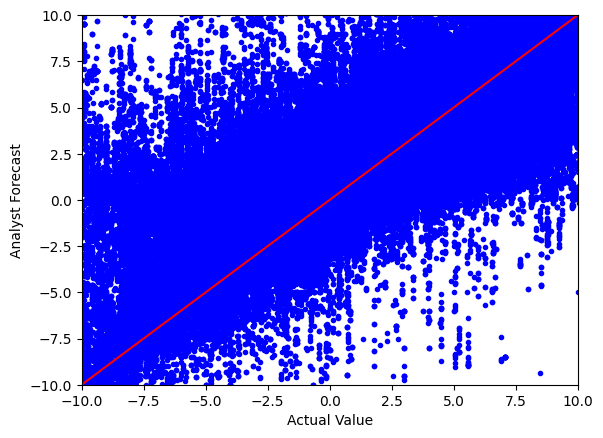

In [27]:
# plot forecast and exact 
plt.plot(IBES_CRSP.adj_actual, IBES_CRSP.meanest, '.', color='blue')
plt.plot([-10,10], [-10,10], 'r-')
plt.xlabel('Actual Value')
plt.ylabel('Analyst Forecast')
plt.xlim(-10,10)
plt.ylim(-10,10)


(-20.0, 20.0)

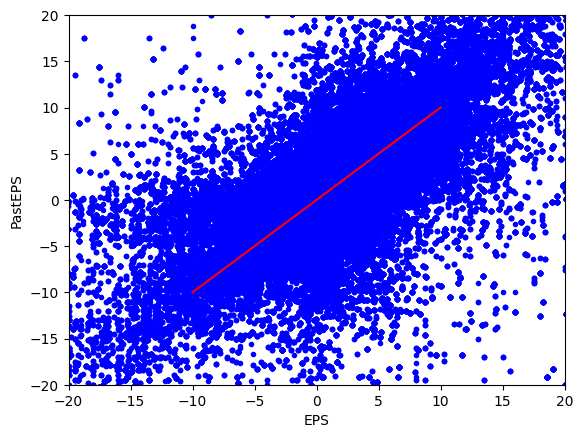

In [28]:
# plot eps and past eps 
plt.plot(IBES_CRSP.adj_past_eps, IBES_CRSP.adj_actual, '.', color='blue')
plt.plot([-10,10], [-10,10], 'r-')
plt.xlabel('EPS')
plt.ylabel('PastEPS')
plt.xlim(-20,20)
plt.ylim(-20,20)

In [29]:
IBES_CRSP.to_csv('data/ibes_crsp.csv')

## Macroeconomic Data

### 1) Read Data and prepared them

In [30]:
GDP_Raw = pd.read_csv('data/real_GDP_FED.csv', index_col=0)
IPT_Raw = pd.read_csv('data/IPT_FED.csv', skiprows=range(1, 620), index_col=0)
IPT_Raw.drop(IPT_Raw.columns[1:121], axis=1, inplace=True)
IPT_Raw.reset_index(inplace=True, drop=True)
Cons_Raw = pd.read_csv('data/real_personal_consumption_FED.csv', index_col=0)
Unempl_Raw = pd.read_csv('data/Unemployment_FED.csv',skiprows=range(1, 225), index_col=0)

In [31]:
GDP_Data = PrepareMacro(GDP_Raw,65,11,'ROUTPUT','GDP');
IPT_Data = PrepareMacro(IPT_Raw,72,11,'IPT','IPT');
Cons_Data = PrepareMacro(Cons_Raw,65,11,'RCON','Cons');

/Users/yandong/Documents/GitHub/Man-vs-machine/functions.py:48: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  B = pd.value_counts(A.isna().values)
/Users/yandong/Documents/GitHub/Man-vs-machine/functions.py:48: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  B = pd.value_counts(A.isna().values)
/Users/yandong/Documents/GitHub/Man-vs-machine/functions.py:48: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  B = pd.value_counts(A.isna().values)


In [32]:
#Different method for unemployemnt because data organised differently
Unempl_Arr = Unempl_Raw.to_numpy()
shape = Unempl_Arr.shape
N = shape[0]
values = []
for i in range(0,N):
    x = Unempl_Arr[i,1:]
    first_non_nan_value = next((value for value in x if not np.isnan(value)), None)
    values.append(first_non_nan_value)

#DataFrame
d = {'Dates':Unempl_Raw['DATE'], 'Unempl':values}
Unempl_Data = pd.DataFrame(data=d)
Unempl_Data['Dates'] = Unempl_Data['Dates'].str.replace(':', '-')
Unempl_Data['Dates'] = pd.to_datetime(Unempl_Data['Dates'], format='%Y-%m')
Unempl_Data.head()

,Dates,Unempl
224,1965-09-01,4.4
225,1965-10-01,4.3
226,1965-11-01,4.2
227,1965-12-01,4.1
228,1966-01-01,4.0


### 2) Take log of the differences (not for unemployment rate)

In [33]:
dfs_difference = [GDP_Data, Cons_Data, IPT_Data ]
cols_difference = ['GDP', 'Cons', 'IPT' ]
count = 0
for df, name in zip(dfs_difference, cols_difference):
    column_name = name + '_' + 'log_return'
    df[column_name] = np.log(df[name] / df[name].shift(1))
    df.dropna(inplace=True)


### 3) Merge 

In [34]:
merged_macro = Unempl_Data
for file in dfs_difference:
    merged_macro = pd.merge(merged_macro,file, on = ['Dates'], how = 'outer')

merged_macro.to_csv('data/processed_data/macro_data.csv')
merged_macro.head()

,Dates,Unempl,GDP,GDP_log_return,Cons,Cons_log_return,IPT,IPT_log_return
0,1965-09-01,4.4,NaN,NaN,NaN,NaN,NaN,NaN
1,1965-10-01,4.3,NaN,NaN,NaN,NaN,NaN,NaN
2,1965-11-01,4.2,NaN,NaN,NaN,NaN,NaN,NaN
3,1965-12-01,4.1,609.7,0.000985,396.7,0.016521,NaN,NaN
4,1966-01-01,4.0,609.7,0.000000,396.7,0.000000,NaN,NaN


## Financial Ratio

### 1) Read and clean data

In [35]:
finratio = pd.read_csv('data/finratio.csv', index_col=0)
finratio.head()

,gvkey,permno,adate,qdate,public_date,capei,be,bm,evm,pe_op_basic,...,ffi30_desc,ffi30,ffi38_desc,ffi38,ffi48_desc,ffi48,ffi49_desc,ffi49,ticker,cusip
0,1001,10015,1983-12-31,1984-09-30,1985-01-31,NaN,9.105,0.551751,7.158486,NaN,...,MEALS,28.0,RTAIL,34.0,MEALS,43.0,MEALS,44.0,AMFD,00016510
1,1001,10015,1984-12-31,1984-12-31,1985-02-28,NaN,9.319,0.696487,5.660224,NaN,...,MEALS,28.0,RTAIL,34.0,MEALS,43.0,MEALS,44.0,AMFD,00016510
2,1001,10015,1984-12-31,1984-12-31,1985-03-31,NaN,9.319,0.696487,5.660224,NaN,...,MEALS,28.0,RTAIL,34.0,MEALS,43.0,MEALS,44.0,AMFD,00016510
3,1001,10015,1984-12-31,1984-12-31,1985-04-30,NaN,9.319,0.696487,5.660224,NaN,...,MEALS,28.0,RTAIL,34.0,MEALS,43.0,MEALS,44.0,AMFD,00016510
4,1001,10015,1984-12-31,1985-03-31,1985-05-31,NaN,9.630,0.491414,6.339642,NaN,...,MEALS,28.0,RTAIL,34.0,MEALS,43.0,MEALS,44.0,AMFD,00016510


In [36]:
print(finratio.columns.tolist())

['gvkey', 'permno', 'adate', 'qdate', 'public_date', 'capei', 'be', 'bm', 'evm', 'pe_op_basic', 'pe_op_dil', 'pe_exi', 'pe_inc', 'ps', 'pcf', 'dpr', 'npm', 'opmbd', 'opmad', 'gpm', 'ptpm', 'cfm', 'roa', 'roe', 'roce', 'efftax', 'aftret_eq', 'aftret_invcapx', 'aftret_equity', 'pretret_noa', 'pretret_earnat', 'gprof', 'equity_invcap', 'debt_invcap', 'totdebt_invcap', 'capital_ratio', 'int_debt', 'int_totdebt', 'cash_lt', 'invt_act', 'rect_act', 'debt_at', 'debt_ebitda', 'short_debt', 'curr_debt', 'lt_debt', 'profit_lct', 'ocf_lct', 'cash_debt', 'fcf_ocf', 'lt_ppent', 'dltt_be', 'debt_assets', 'debt_capital', 'de_ratio', 'intcov', 'intcov_ratio', 'cash_ratio', 'quick_ratio', 'curr_ratio', 'cash_conversion', 'inv_turn', 'at_turn', 'rect_turn', 'pay_turn', 'sale_invcap', 'sale_equity', 'sale_nwc', 'rd_sale', 'adv_sale', 'staff_sale', 'accrual', 'ret_crsp', 'gsector', 'gicdesc', 'mktcap', 'price', 'ptb', 'peg_trailing', 'divyield', 'peg_1yrforward', 'peg_ltgforward', 'ffi5_desc', 'ffi5', 'ff

In [37]:
#We exclude PEG 1yrforward, PEG ltgforward, pe op basic, and pe op dil from our forecast model, because these variables have too many missing observations.
finratio.drop(['peg_1yrforward', 'peg_ltgforward', 'pe_op_basic', 'pe_op_dil', 'price', 'ret_crsp'], axis=1, inplace=True)

In [38]:
finratio['public_date'] = pd.to_datetime(finratio['public_date'].astype('str'))
finratio.drop(['gvkey', 'adate', 'qdate',  'ticker', 'cusip', 'ffi5_desc', 'ffi5', 'ffi10_desc', 'ffi10', 'ffi12_desc', 'ffi12', 'ffi17_desc', 'ffi17',
                'ffi30_desc', 'ffi30', 'ffi38_desc', 'ffi38', 'ffi48_desc', 'ffi48', 'ffi49_desc','gsector', 'gicdesc' ], axis=1, inplace=True)

In [39]:
vars_winsorize = list(finratio.drop(['permno'], axis=1).columns)

In [40]:
finratio = finratio.dropna(axis=0, subset=['ffi49'])

In [41]:
foo = finratio.groupby(['public_date', 'ffi49'])[vars_winsorize]
foo.transform(lambda x: x.median(skipna=True))

,public_date,capei,be,bm,evm,pe_exi,pe_inc,ps,pcf,dpr,...,sale_nwc,rd_sale,adv_sale,staff_sale,accrual,mktcap,ptb,peg_trailing,divyield,ffi49
0,1985-01-31,15.038979,21.441,0.555475,6.887222,13.85386,13.876262,0.586076,6.496665,0.0,...,16.424335,0.0,0.025017,0.0,-0.053217,41.699187,1.838327,0.455015,0.013529,44.0
1,1985-02-28,14.545138,20.444,0.594367,6.521488,14.447753,14.199309,0.622112,6.932156,0.0,...,17.843082,0.0,0.025503,0.0,-0.059936,39.356375,1.934553,0.642836,0.012262,44.0
2,1985-03-31,14.333423,20.607,0.594367,6.64799,14.612676,13.835878,0.629638,7.755468,0.0,...,19.075643,0.0,0.025503,0.0,-0.050433,40.851687,2.000044,0.633807,0.01194,44.0
3,1985-04-30,14.846556,20.769,0.57947,6.64799,14.60177,13.878676,0.627507,7.465128,0.0,...,20.308204,0.0,0.025638,0.0,-0.05239,38.124625,1.866355,0.599096,0.013161,44.0
4,1985-05-31,14.755264,21.3765,0.563479,7.219646,14.351851,14.351851,0.649408,8.099452,0.01931,...,17.09865,0.0,0.025638,0.0,-0.047442,38.108563,1.858097,0.633334,0.012121,44.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
277898,2025-08-31,13.613695,486.682,0.418668,11.885019,14.807018,14.454795,1.716192,10.044405,0.0,...,5.438214,0.0,0.0,0.0,-0.056652,878.1032,2.511027,0.078874,0.01995,34.0
277899,2025-09-30,13.399771,435.689,0.41696,11.885019,14.971488,14.426768,1.657127,9.688027,0.0,...,5.491716,0.0,0.0,0.0,-0.056652,815.247665,2.506673,0.078661,0.019882,34.0
277900,2025-10-31,12.509212,435.689,0.41696,11.885019,13.468186,13.245599,1.754105,9.034143,0.0,...,5.491716,0.0,0.0,0.0,-0.056652,831.69629,2.421248,0.077311,0.018333,34.0
277901,2025-11-30,13.095108,492.8805,0.400254,10.910427,12.563126,11.450292,1.604619,9.083069,0.00972,...,5.288522,0.0,0.0,0.0,-0.058249,776.523195,2.13206,0.203882,0.018771,34.0


In [42]:
# Replace NA with the industry median
finratio.loc[:, vars_winsorize] = finratio.groupby(['public_date', 'ffi49'])[vars_winsorize].transform(lambda x: x.fillna(x.median(skipna=True)));
print(finratio[vars_winsorize].isna().sum().sum())

# Replace remaining NA values with last month's value
finratio.loc[:, vars_winsorize] = finratio.groupby('permno')[vars_winsorize].transform(lambda x: x.ffill().bfill());
print(finratio[vars_winsorize].isna().sum().sum())

# Replace any remaining NA with the industry median again
finratio.loc[:, vars_winsorize] = finratio.groupby(['public_date', 'ffi49'])[vars_winsorize].transform(lambda x: x.fillna(x.median(skipna=True)));
print(finratio[vars_winsorize].isna().sum().sum())


1386
0
0


In [43]:
for column in finratio.columns:
    na_count = finratio[column].isna().sum()
    if na_count > 0:
        print(f"{column}: {na_count}")

### 2) Merge FinRatio with IBES_CRSP

In [44]:
# create past_eps_ add atual of anndats_act closer and before statpers
IBES_CRSP = IBES_CRSP.sort_values(by=['permno','statpers'], ascending=True)
IBES_CRSP.statpers = pd.to_datetime(IBES_CRSP.statpers)
finratio = finratio.sort_values(by=['permno','public_date'], ascending=True)

IBES_CRSP.permno = IBES_CRSP.permno.astype(int)
finratio.permno = finratio.permno.astype(int)

data = pd.merge_asof( IBES_CRSP.set_index('statpers').sort_index(),
                    finratio.set_index('public_date',drop=False).sort_index(),
                    left_index=True, 
                    right_index=True,
                    by = 'permno',
                    direction='backward')  

data = data.reset_index()
data.sort_values(by=['permno','rankdate'], ascending=True)
data.tail()

,statpers,permno,price,ret,Unnamed: 0,ticker,cusip,cname,fpedats,meanest,...,sale_nwc,rd_sale,adv_sale,staff_sale,accrual,mktcap,ptb,peg_trailing,divyield,ffi49
5236440,2024-12-19,93397,25.660,0.011830,192353,LMNR,53274610,LIMONEIRA,2024-10-31,0.63,...,2.772521,0.000000,0.000000,0.0,-0.006040,502.707400,2.449579,-0.000162,0.010791,1.0
5236441,2024-12-19,47511,21.030,0.008150,373062,EBF,29338910,ENNIS,2024-11-30,0.39,...,2.358845,0.000000,0.001190,0.0,-0.069646,554.665320,1.508793,0.923106,0.046882,39.0
5236442,2024-12-19,25143,17.140,-0.052515,381828,GRAL,38474710,GRAIL,2024-06-30,-51.06,...,0.189099,7.564762,0.235218,0.0,-0.044428,588.017500,0.198470,-0.022453,0.032633,13.0
5236443,2024-12-19,24810,0.653,0.106780,214961,052G,17112610,CHANNEL,2024-06-30,-3.10,...,0.361607,0.000000,0.000000,0.0,-2.579539,3.683108,2.306379,-0.022453,0.032633,13.0
5236444,2024-12-19,16857,2.570,-0.007722,283095,CTXR,17322U30,CITIUS PHARMS,2024-09-30,-1.53,...,0.361607,0.000000,0.000000,0.0,-0.099318,24.000280,0.312540,-0.349984,0.032633,13.0


In [45]:
print(data.columns.tolist())

['statpers', 'permno', 'price', 'ret', 'Unnamed: 0', 'ticker', 'cusip', 'cname', 'fpedats', 'meanest', 'fpi', 'numest', 'announcement_actual_eps', 'rankdate', 'adjust_factor', 'adj_actual', 'announcement_past_ep', 'adj_past_eps', 'public_date', 'capei', 'be', 'bm', 'evm', 'pe_exi', 'pe_inc', 'ps', 'pcf', 'dpr', 'npm', 'opmbd', 'opmad', 'gpm', 'ptpm', 'cfm', 'roa', 'roe', 'roce', 'efftax', 'aftret_eq', 'aftret_invcapx', 'aftret_equity', 'pretret_noa', 'pretret_earnat', 'gprof', 'equity_invcap', 'debt_invcap', 'totdebt_invcap', 'capital_ratio', 'int_debt', 'int_totdebt', 'cash_lt', 'invt_act', 'rect_act', 'debt_at', 'debt_ebitda', 'short_debt', 'curr_debt', 'lt_debt', 'profit_lct', 'ocf_lct', 'cash_debt', 'fcf_ocf', 'lt_ppent', 'dltt_be', 'debt_assets', 'debt_capital', 'de_ratio', 'intcov', 'intcov_ratio', 'cash_ratio', 'quick_ratio', 'curr_ratio', 'cash_conversion', 'inv_turn', 'at_turn', 'rect_turn', 'pay_turn', 'sale_invcap', 'sale_equity', 'sale_nwc', 'rd_sale', 'adv_sale', 'staff_sa

In [46]:
data.drop(['Unnamed: 0'], axis=1, inplace=True)
print(data.shape)

(5236445, 88)


## FINAL: Dataset divided by FPI

In [47]:
A1 = data[data.fpi == 1].reset_index(drop=True)
A2= data[data.fpi == 2].reset_index(drop=True)
Q1 = data[data.fpi == 6].reset_index(drop=True)
Q2 = data[data.fpi == 7].reset_index(drop=True)
Q3 = data[data.fpi == 8].reset_index(drop=True)

In [48]:
for Forecast in [A1, A2, Q1, Q2, Q3]:
    df_name = next(name for name, obj in globals().items() if obj is Forecast)
    Forecast.dropna(subset=['adj_actual', 'meanest', 'adj_past_eps'], inplace=True)
    Forecast.sort_values(by=['permno', 'rankdate'], ascending=True, inplace=True)
    Forecast.reset_index(drop=True, inplace=True)
    Forecast.to_csv(f"data/processed_data/{df_name}.csv", index=False)